Importing Libraries

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import (ttest_ind, f_oneway, chi2_contingency)

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/interim/cleaned_day2.csv")
df.head()

,Accident_ID,Accident_Date,Accident_Time,Report_Timestamp,District,Road_Type,Weather_Condition,Surface_Condition,Light_Condition,Traffic_Density,Vehicle_Type,Driver_Age,Driver_Gender,Alcohol_Involved,Vehicle_Speed_kmph,Helmet_Used,Seatbelt_Used,Cause_Category,Accident_Severity,Casualties_Count,Injury_Type,Emergency_Response_Time_Min
0,Ker_Acc_100000,2023-04-25,00:47:00,2023-04-25 02:02:00,Kozhikode,Bridge,Clear,Dry,Night,Medium,Truck,23,Male,No,90,Not Applicable,No,Drunk Driving,Minor,1,No Injury,6.0
1,Ker_Acc_100031,2024-06-01,19:01:00,2024-06-01 21:29:00,Alappuzha,Urban Road,Clear,Dry,Night,Medium,Motorcycle,32,Female,No,58,Yes,Not Applicable,Mechanical Failure,Minor,1,No Injury,13.0
2,Ker_Acc_100002,2025-04-05,05:44:00,2025-04-05 07:37:00,Kannur,Rural Road,Clear,Wet,Night,Low,Car,24,Female,Yes,54,Not Applicable,Yes,Mechanical Failure,Serious,1,Minor Injury,13.0
3,Ker_Acc_100003,2023-09-28,01:46:00,2023-09-28 03:48:00,Malappuram,Junction,Clear,Dry,Night,Medium,Car,53,Female,No,32,Not Applicable,Yes,Weather Conditions,Minor,2,Minor Injury,25.0
4,Ker_Acc_100004,2023-07-16,22:04:00,2023-07-16 22:20:00,Malappuram,Highway,Fog,Dry,Night,Medium,Car,32,Female,No,112,Not Applicable,Yes,Weather Conditions,Serious,2,Major Injury,22.0


SECTION 1: Datetime Conversion

In [32]:
df['Accident_Date'] = pd.to_datetime(df['Accident_Date'])

df['Report_Timestamp'] = pd.to_datetime(df['Report_Timestamp'])

df['Accident_Time'] = pd.to_datetime(df['Accident_Time'], format='%H:%M:%S').dt.hour

In [33]:
print(df['Accident_Date'].dtype)
print(df['Accident_Time'].dtype)
print(df['Report_Timestamp'].dtype)

datetime64[us]
int32
datetime64[us]


In [34]:
df.rename(
    columns={'Accident_Time': 'Accident_Hour'},
    inplace=True
)

SECTION 2: Feature Engineering

In [35]:
df['Accident_Year'] = (df['Accident_Date'].dt.year)

df['Accident_Month'] = (df['Accident_Date'].dt.month_name())

df['Day_Of_Week'] = (df['Accident_Date'].dt.day_name())

df['Is_Weekend'] = (df['Day_Of_Week'].isin(['Saturday','Sunday']))

Time Block

In [36]:
def time_block(hour):
    if hour < 6:
        return "Late Night"
    elif hour < 12:
        return "Morning"
    elif hour < 18:
        return "Afternoon"
    else:
        return "Evening"
    
df['Time_Block'] = (
    df['Accident_Hour']
    .apply(time_block)
)

Age Group

In [37]:
df['Age_Group'] = pd.cut(
    df['Driver_Age'],
    bins=[0,25,40,60,100],
    labels=[
        'Young',
        'Adult',
        'Middle Age',
        'Senior'
    ]
)

df['Age_Group'].value_counts()

Age_Group
Middle Age    2307
Adult         1539
Senior        1027
Young          837
Name: count, dtype: int64

High Speed Flag

In [38]:
df['High_Speed'] = np.where(
    df['Vehicle_Speed_kmph'] > 80, 'Yes', 'No'
)

df['High_Speed'].value_counts()

High_Speed
No     3789
Yes    1921
Name: count, dtype: int64

Delayed Response

In [39]:
df['Delayed_Response'] = np.where(
    df['Emergency_Response_Time_Min'] > 20, 'Yes', 'No'
)

df['Delayed_Response'].value_counts()

Delayed_Response
No     3386
Yes    2324
Name: count, dtype: int64

Night Driving

In [40]:
df['Night_Driving'] = np.where(
    (df['Accident_Hour'] < 6) | (df['Accident_Hour'] >= 18), 'Yes', 'No'
)

df['Night_Driving'].value_counts()

Night_Driving
No     2891
Yes    2819
Name: count, dtype: int64

Multiple Casualties

In [41]:
df['Multiple_Casualties'] = np.where(
    df['Casualties_Count'] > 1, 'Yes', 'No'
)

df['Multiple_Casualties'].value_counts()

Multiple_Casualties
Yes    3028
No     2682
Name: count, dtype: int64

Time-Based EDA

Monthly Accident Distribution

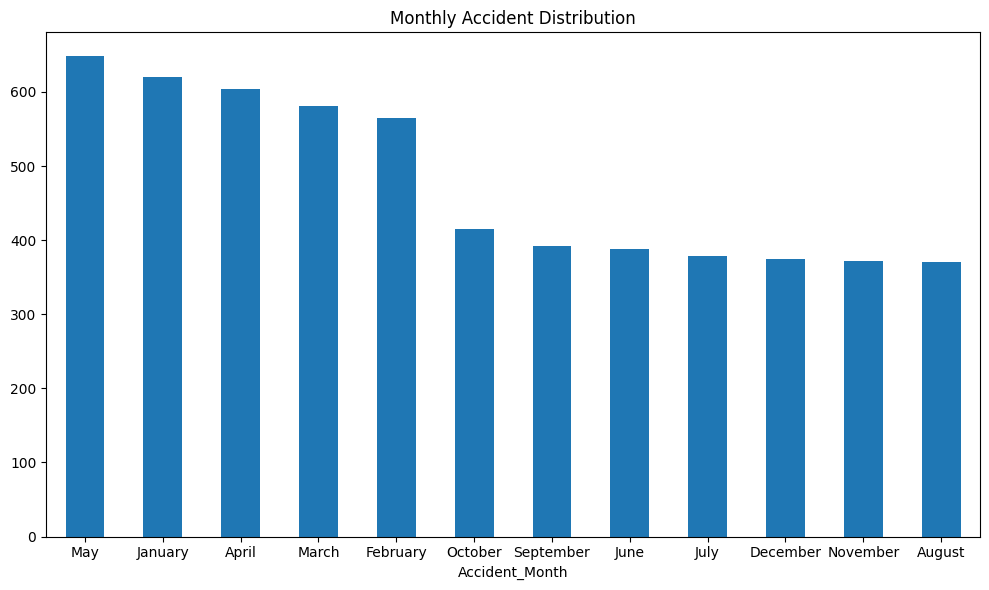

In [42]:
monthly = (df['Accident_Month'].value_counts())

monthly.plot(kind='bar', figsize=(10,6))
plt.title("Monthly Accident Distribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../reports/figures/monthly_accidents.png")
plt.show()

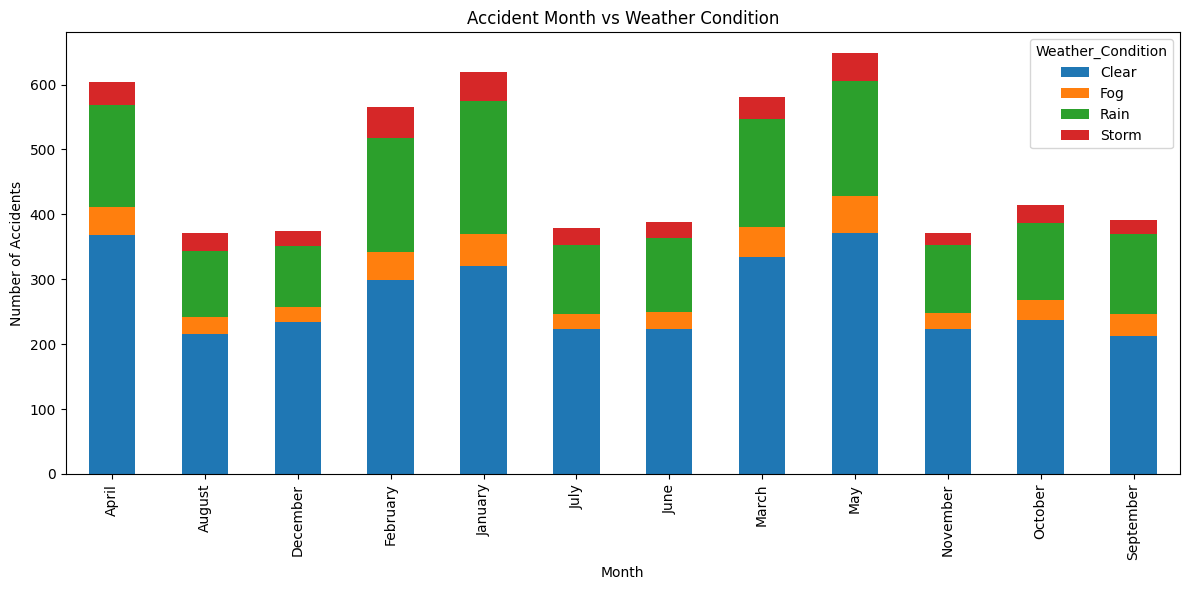

In [43]:
month_weather = pd.crosstab(df['Accident_Month'], df['Weather_Condition'])

month_weather.plot(kind='bar', stacked=True, figsize=(12,6))

plt.title("Accident Month vs Weather Condition")
plt.xlabel("Month")
plt.ylabel("Number of Accidents")
plt.tight_layout()
plt.show()

Accidents by Weekday

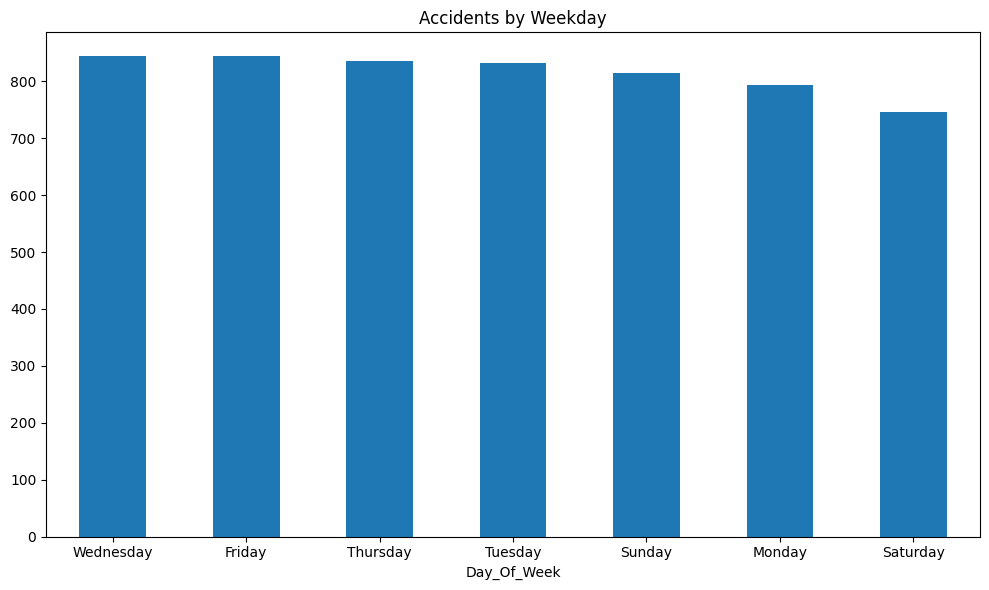

In [44]:
weekday = (df['Day_Of_Week'].value_counts())

weekday.plot(kind='bar', figsize=(10,6))
plt.title("Accidents by Weekday")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../reports/figures/weekday_accidents.png")
plt.show()

Hourly Accident Trend

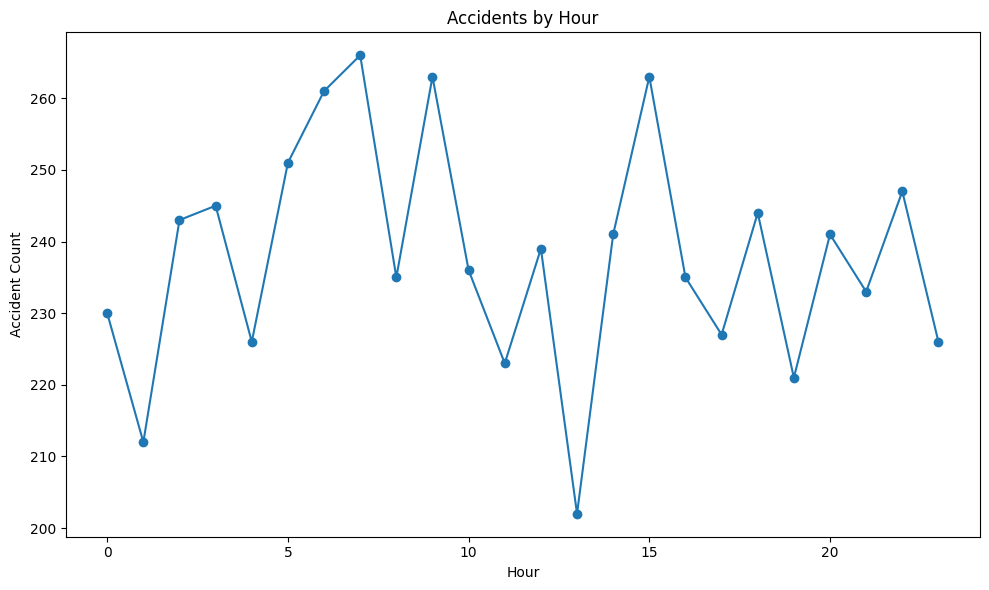

In [45]:
hourly = (df['Accident_Hour'].value_counts().sort_index())

hourly.plot(kind='line', marker='o', figsize=(10,6))
plt.title("Accidents by Hour")
plt.xlabel("Hour")
plt.ylabel("Accident Count")
plt.tight_layout()
plt.savefig("../reports/figures/hourly_accidents.png")
plt.show()

Time Block Analysis

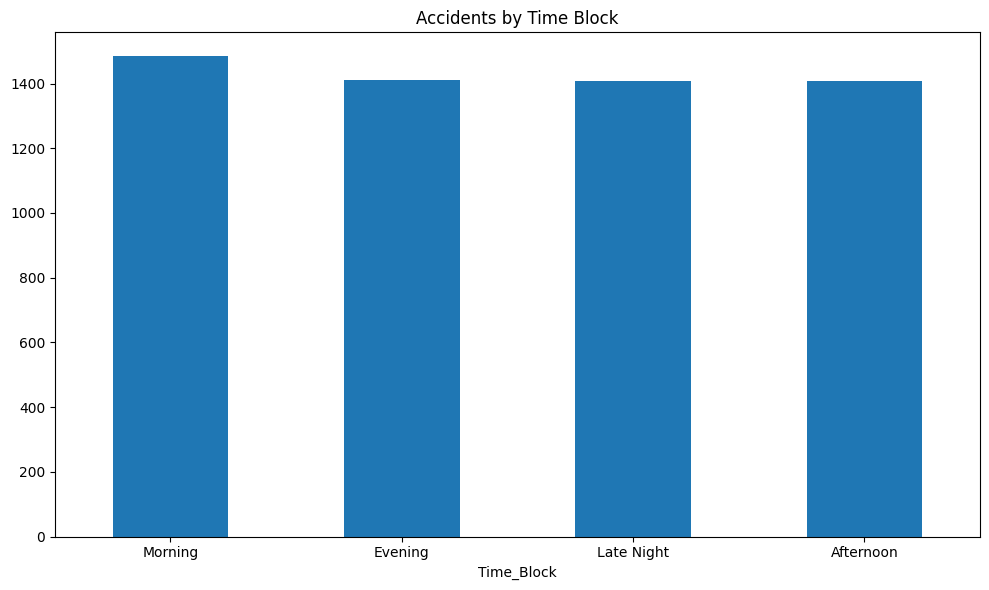

In [46]:
time_blocks = (df['Time_Block'].value_counts())

time_blocks.plot(kind='bar', figsize=(10,6))
plt.title("Accidents by Time Block")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../reports/figures/time_block_accidents.png")
plt.show()

Weekend vs Weekday Accidents

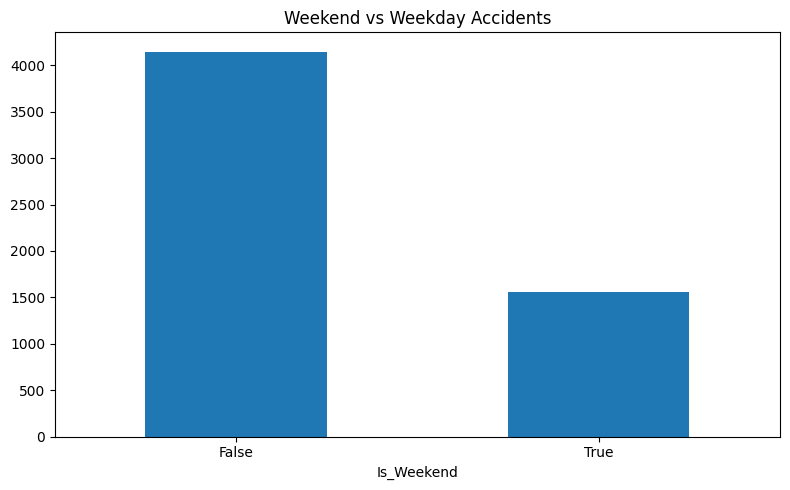

In [47]:
weekend_analysis = (df['Is_Weekend'].value_counts())

weekend_analysis.plot(kind='bar', figsize=(8,5))
plt.title("Weekend vs Weekday Accidents")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../reports/figures/weekend_accidents.png")
plt.show()

SECTION 4: Statistical Tests

A. Independent T-Test

In [48]:
fatal = df[df['Accident_Severity'] == 'Fatal']['Vehicle_Speed_kmph'] 
minor = df[df['Accident_Severity'] == 'Minor']['Vehicle_Speed_kmph']

t_stat, p_value = ttest_ind(fatal, minor)

print("T Statistic:", t_stat)
print("P Value:", p_value)

T Statistic: 13.914323705091272
P Value: 6.9126187264447464e-43


In [49]:
if p_value < 0.05:
    print(
        "Significant difference in speed between Fatal and Minor accidents."
    )
else:
    print(
        "No significant difference in speed between Fatal and Minor accidents."
    )

Significant difference in speed between Fatal and Minor accidents.


B. ANOVA Test

In [50]:
groups = []

for road in df['Road_Type'].unique():
    groups.append(
        df[df['Road_Type'] == road]['Emergency_Response_Time_Min']
    )

f_stat, p_value = f_oneway(*groups)

print("F Statistic:", f_stat)
print("P Value:", p_value)

F Statistic: 21.503013490388017
P Value: 1.2568330550652589e-17


In [51]:
if p_value < 0.05:
    print(
        "Emergency response time differs significantly across road types."
    )
else:
    print(
        "No significant difference in emergency response time across road types."
    )

Emergency response time differs significantly across road types.


C. Chi-Square Test

In [52]:
helmet_df = df[df['Helmet_Used'] != 'Not Applicable']

In [53]:
contingency = pd.crosstab(
    helmet_df['Helmet_Used'],
    helmet_df['Accident_Severity']
)

contingency

Accident_Severity,Fatal,Minor,Serious
Helmet_Used,,,
No,10,144,212
Yes,55,621,797


In [54]:
chi2, p_value, dof, expected = (
    chi2_contingency(contingency)
)

print("Chi-Square:", chi2)
print("P Value:", p_value)

Chi-Square: 2.168560480070265
P Value: 0.33814508161901485


In [55]:
if p_value < 0.05:
    print(
        "Helmet usage and accident severity are significantly associated."
    )
else:
    print(
        "Helmet usage and accident severity are not significantly associated."
    )

Helmet usage and accident severity are not significantly associated.


SECTION 5: Advanced Risk Factor Analysis

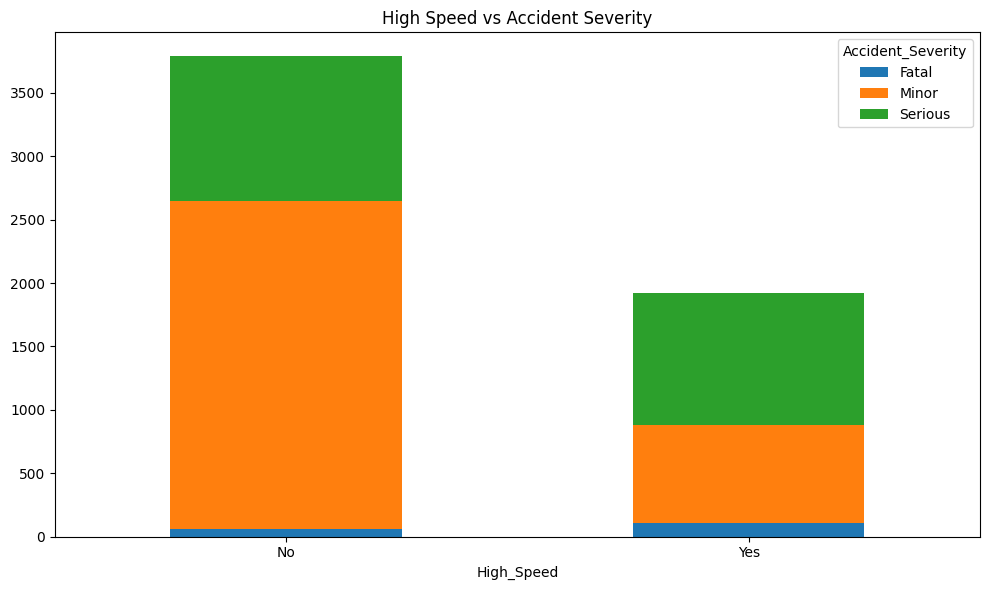

In [56]:
speed_severity = pd.crosstab(df['High_Speed'], df['Accident_Severity'])

speed_severity.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("High Speed vs Accident Severity")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../reports/figures/high_speed_severity.png")
plt.show()

Alcohol Involvement vs Severity

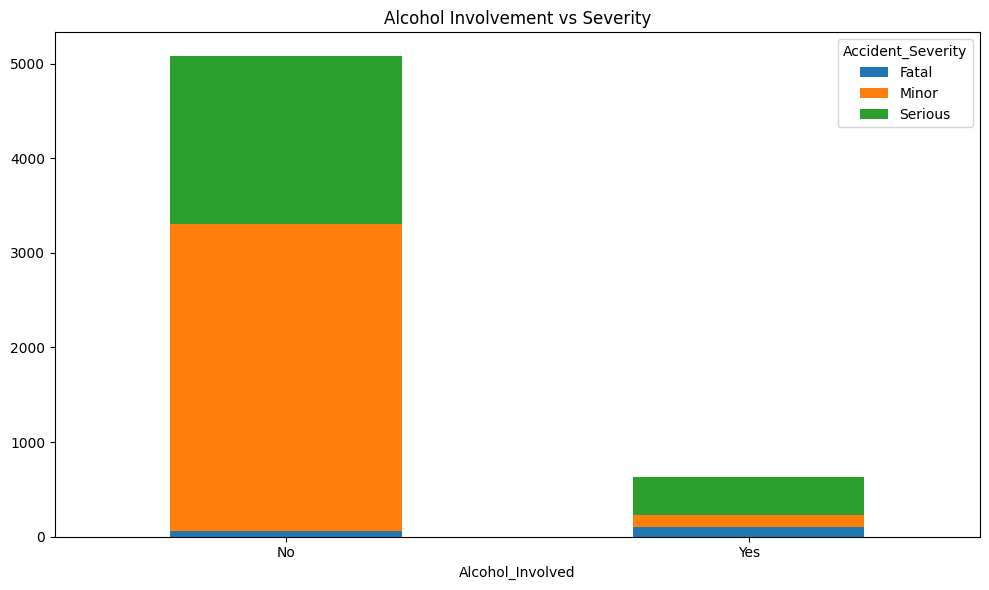

In [57]:
alcohol_severity = pd.crosstab(df['Alcohol_Involved'],df['Accident_Severity'])

alcohol_severity.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Alcohol Involvement vs Severity")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../reports/figures/alcohol_severity.png")
plt.show()

Night Driving vs Severity

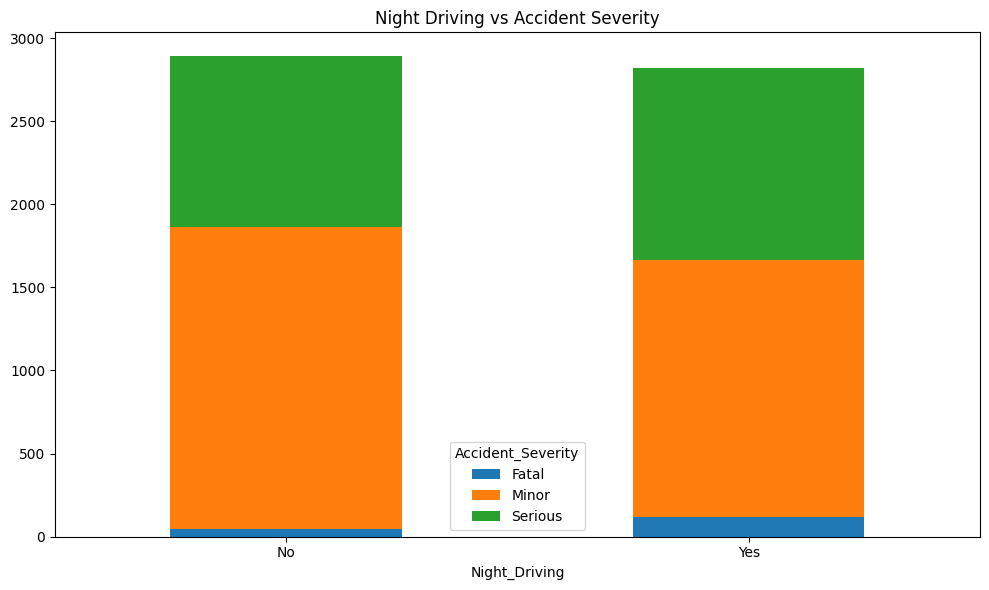

In [58]:
night_severity = pd.crosstab(df['Night_Driving'],df['Accident_Severity'])

night_severity.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Night Driving vs Accident Severity")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../reports/figures/night_driving_severity.png")
plt.show()

Age Group vs Severity

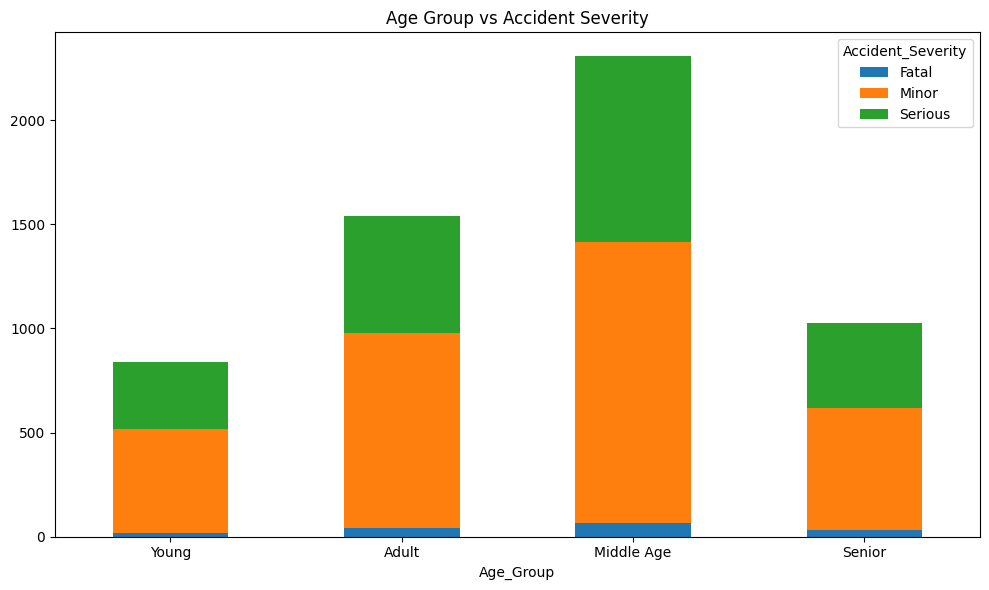

In [59]:
age_severity = pd.crosstab(df['Age_Group'],df['Accident_Severity'])

age_severity.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Age Group vs Accident Severity")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../reports/figures/age_group_severity.png")
plt.show()

SECTION 6: Save Final Dataset

In [60]:
df.to_csv("../data/processed/final_cleaned_day4.csv", index=False)

SECTION 7: Initial Insights

Key Findings

Time-Based Analysis

1. Most accidents occurred during 7 and 15.
2. Wednesday had the highest number of accidents.
3. May recorded the most accidents.
4. More accidents occurred on Weekdays.

Statistical Tests

T-Test

1. P-value: 6.9126187264447464e-43
2. Conclusion: Significant

ANOVA

1. P-value: 1.2568330550652589e-17
2. Conclusion: Significant

Chi-Square Test

1. P-value: 0.33814508161901485
2. Conclusion: NotSignificant

Driver and Vehicle Insights

1. High-speed vehicles were involved in less severe accidents.
2. Middle-Age drivers were involved in the most accidents.
3. Alcohol involvement showed lower accident severity.
4. Night-time accidents were less severe.

<!--  -->

SECTION 1: Top 10 Insights

Top 10 Insights

1. The highest number of accidents occurred during 7am and 3pm.
2. Wednesday recorded the most accidents among all weekdays.
3. May had the highest accident frequency.
4. Malappuram was the most accident-prone district.
5. Higher vehicle speeds doesnt mean more severe accidents.
6. Helmet usage was associated with higher accident severity.
7. Seatbelt usage was associated with higher accident severity.
8. Night-time accidents showed different severity patterns compared to daytime accidents.
9. Emergency response time varied across different road types.
10. Alcohol involvement showed a relationship with accident severity.

SECTION 2: Data Quality Summary

Issue	                        Status

Missing Values	                Handled
Duplicate Records	            Removed
Outliers	                    Detected and Treated
Datatype Issues	                Corrected
Categorical Inconsistencies	    Standardized

Project Summary

This project performed a complete Exploratory Data Analysis (EDA) on a Kerala Road Accident dataset.

The workflow included:

1. Data understanding
2. Data cleaning
3. Missing value treatment
4. Duplicate removal
5. Outlier detection and treatment
6. Univariate analysis
7. Bivariate analysis
8. Statistical testing
9. Time-based analysis
10. Feature engineering
11. Insight generation

The objective was to identify accident patterns and factors associated with accident severity.